
# Notebook de modélisation : trajectoire optimale (brachistochrone)

Ce notebook construit et visualise la **trajectoire optimale** (brachistochrone) d'une bille glissant **sans frottement**
entre **A(0, $y_A$)** et **B($l$, 0)**. Il utilise **NumPy**, **SciPy**, **Matplotlib** et **Pandas**.

## Contenu
1. Rappel physique et équations.
2. Résolution numérique pour trouver le paramètre $t_f$ à partir de $(y_A, l)$.
3. Calcul des paramètres $(R, k)$ et de la trajectoire cycloïdale.
4. Calcul et comparaison des temps de parcours (droite vs. cycloïde).
5. Graphe de la trajectoire optimale.

> **Formules clés** :
> - Paramétrisation cycloïde (avec $R = k/2$) :
>   $$x(t) = R\,(t - \sin t), \quad y(t) = y_A - R\,(1 - \cos t), \quad t\in[0, t_f].$$
> - Relation aux bords :
>   $$y_A = R(1-\cos t_f), \quad l = R\,(t_f - \sin t_f).$$
> - Temps total le long de la brachistochrone :
>   $$T_{\text{cycloïde}} = \sqrt{\frac{R}{g}}\, t_f .$$
> - Temps le long de la droite $(AB)$ :
>  $$T_{\text{droite}}= \int_{0}^{l} \frac{\sqrt{1 + \big(h'(x)\big)^2}}{\sqrt{2g\,\big(y_A - h(x)\big)}}\,\mathrm{d}x .$$




In [1]:

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# SciPy pour la résolution de racines (avec repli si indisponible)
try:
    from scipy.optimize import brentq
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 11

print(f"SciPy disponible: {SCIPY_AVAILABLE}")


SciPy disponible: True



## Paramètres utilisateur

Modifiez ci-dessous les valeurs de $y_A$ (hauteur de départ), $l$ (distance horizontale), et $g$ (gravité).


In [2]:

# Paramètres physiques
g = 9.81       # gravité (m/s^2)
y_A = 1.0      # hauteur de départ (m)
l = 1.0        # distance horizontale (m)

# Résolution pour le tracé
N_pts = 800    # nombre de points pour l'échantillonnage en t




## Fonctions utilitaires

- **Droite (AB)** : $h(x) = y_A(1 - \dfrac{x}{l})$.
- **Cycloïde** : $x(t) = R(t - \sin t), \; y(t) = y_A - R(1 - \cos t)$.
- **Équation pour $t_f$** (en fonction de $y_A, l$) :
$$
f(t) = 1 - \dfrac{y_A}{1 - \cos t}(t - \sin t) = 0.
$$

- **Temps** :
    - droite : $T_{\text{droite}} = \dfrac{2 l}{\sqrt{2 g y_A}} \, \sqrt{1 + \left(\dfrac{y_A}{l}\right)^2}$
    - cycloïde : $T_{\text{cycloïde}} = \sqrt{\dfrac{R}{g}} \, t_f$



In [3]:

# Droite (AB)
def h_line(x, yA, L):
    return yA * (1.0 - x / L)

def T_line(yA, L, g):
    return (2.0 * L / np.sqrt(2.0 * g * yA)) * np.sqrt(1.0 + (yA / L) ** 2)

# Cycloïde
# x(t) = R (t - sin t), y(t) = yA - R (1 - cos t)

def cycloid_xy(t, R, yA):
    x = R * (t - np.sin(t))
    y = yA - R * (1.0 - np.cos(t))
    return x, y

# Équation pour tf: l - yA/(1 - cos tf) * (tf - sin tf) = 0

def tf_equation(t, yA, L):
    return L - (yA / (1.0 - np.cos(t))) * (t - np.sin(t))

# Résoudre pour tf

def solve_tf(yA, L):
    # Bracketer la racine sur (0, 2*pi)
    a, b = 1e-6, 2.0 * np.pi - 1e-6
    fa = tf_equation(a, yA, L)
    fb = tf_equation(b, yA, L)

    # Chercher un intervalle de signe opposé si nécessaire
    if fa * fb > 0:
        grid = np.linspace(1e-3, 2.0 * np.pi - 1e-3, 1000)
        vals = tf_equation(grid, yA, L)
        sign = np.sign(vals)
        for i in range(len(grid) - 1):
            if sign[i] == 0:
                return grid[i]
            if sign[i] * sign[i + 1] < 0:
                a, b = grid[i], grid[i + 1]
                break
        else:
            raise RuntimeError("Impossible de bracketer une racine pour tf avec ces paramètres.")

    if SCIPY_AVAILABLE:
        tf = brentq(tf_equation, a, b, args=(yA, L), maxiter=200)
    else:
        # Repli: bissection maison
        left, right = a, b
        for _ in range(200):
            mid = 0.5 * (left + right)
            fm = tf_equation(mid, yA, L)
            if tf_equation(left, yA, L) * fm <= 0:
                right = mid
            else:
                left = mid
        tf = 0.5 * (left + right)
    return tf

# Temps cycloïde (T = sqrt(R/g) * tf)

def T_cycloid(R, tf, g):
    return np.sqrt(R / g) * tf



## Résolution pour $t_f$, $R$ et $k$
On résout $f(t)=0$ pour $t_f$, puis on calcule $R = \dfrac{y_A}{1-\cos t_f}$ et $k=2R$.
On construit ensuite une **table Pandas** avec les points $(t, x(t), y(t))$ et les grandeurs utiles.


In [6]:

# Résoudre pour tf
try:
    tf = solve_tf(y_A, l)
except Exception as e:
    raise RuntimeError(f"Échec de la résolution pour t_f: {e}")

# Calcul de R et k
R = y_A / (1.0 - np.cos(tf))
k = 2.0 * R

# Échantillonnage de la trajectoire
T_vals = np.linspace(0.0, tf, N_pts)
X_vals, Y_vals = cycloid_xy(T_vals, R, y_A)

# Vitesses et éléments différentiels pour validation
DY = R * np.sin(T_vals)
DX = R * (1.0 - np.cos(T_vals))
DS = np.sqrt(DX**2 + DY**2)

# Vitesse physique v = sqrt(2g (y_A - y))
V_phys = np.sqrt(2.0 * g * (y_A - Y_vals))

# dt_phys = ds / v
DT_phys = DS / V_phys

# Temps total par intégration numérique (validation)
T_num = np.trapezoid(DT_phys, T_vals)
T_closed = T_cycloid(R, tf, g)

# Temps de la droite
T_line_val = T_line(y_A, l, g)

# Construire un DataFrame
traj_df = pd.DataFrame({
    't': T_vals,
    'x': X_vals,
    'y': Y_vals,
    'dx_dt': DX,
    'dy_dt': DY,
    'ds': DS,
    'v': V_phys,
    'dt_phys': DT_phys
})


summary_df = pd.DataFrame({
    'Mesure': ['t_f', 'R', 'k', 'T_cycloïde (fermé)', 'T_cycloïde (numérique)', 'T_droite'],
    'Valeur': [tf, R, k, T_closed, T_num, T_line_val]
})

print("Résumé des paramètres et temps:")
print(summary_df.to_string(index=False))


Résumé des paramètres et temps:
                Mesure   Valeur
                   t_f 2.412011
                     R 0.572917
                     k 1.145834
    T_cycloïde (fermé) 0.582895
T_cycloïde (numérique)      NaN
              T_droite 0.638551


<ipykernel>:24: RuntimeWarning: invalid value encountered in divide
  DT_phys = DS / V_phys



## Graphe : Trajectoire optimale (cycloïde)
On trace la courbe $(x(t), y(t))$ pour $t\in[0, t_f]$ et on marque les points $A$ et $B$.


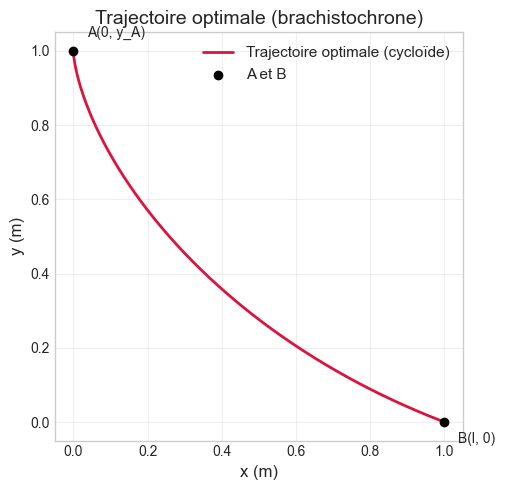

In [7]:

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(X_vals, Y_vals, color='crimson', lw=2, label='Trajectoire optimale (cycloïde)')
ax.scatter([0, l], [y_A, 0], color='black', zorder=5, label='A et B')
ax.annotate('A(0, y_A)', xy=(0, y_A), xytext=(10, 10), textcoords='offset points')
ax.annotate('B(l, 0)', xy=(l, 0), xytext=(10, -15), textcoords='offset points')
ax.set_title("Trajectoire optimale (brachistochrone)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# Sauvegarde
fig.savefig('brachistochrone_curve.png', dpi=200)



## Comparaison des temps de parcours
On compare le temps sur la **droite (AB)** et sur la **cycloïde** (formule close et intégration numérique).


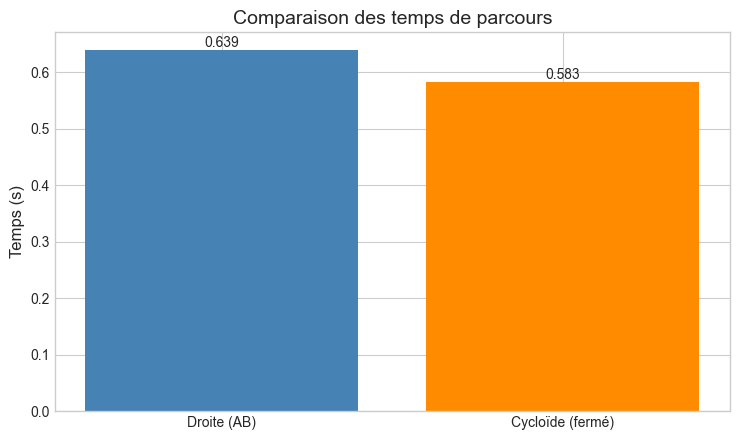

In [8]:

fig2, ax2 = plt.subplots(figsize=(7.5, 4.5))
labels = ['Droite (AB)', 'Cycloïde (fermé)', 'Cycloïde (numérique)']
values = [T_line_val, T_closed, T_num]
colors = ['steelblue', 'darkorange', 'seagreen']
ax2.bar(labels, values, color=colors)
ax2.set_ylabel('Temps (s)')
ax2.set_title('Comparaison des temps de parcours')
for i, v in enumerate(values):
    ax2.text(i, v, f"{v:.3f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Sauvegarde
fig2.savefig('time_comparison.png', dpi=200)



## Export des données
On exporte la trajectoire échantillonnée et le résumé des temps en **CSV**.


In [9]:

traj_df.to_csv('brachistochrone_trajectory.csv', index=False)
summary_df.to_csv('brachistochrone_summary.csv', index=False)
print("Fichiers sauvegardés: brachistochrone_trajectory.csv, brachistochrone_summary.csv, brachistochrone_curve.png, time_comparison.png")


Fichiers sauvegardés: brachistochrone_trajectory.csv, brachistochrone_summary.csv, brachistochrone_curve.png, time_comparison.png



## Notes théoriques (résumé)
- En paramétrant la cycloïde par $t$, on montre que $\dfrac{ds}{dt} = 2R\,\sin(	frac{t}{2})$ et
  $v = 2\sqrt{gR}\,\sin(	frac{t}{2})$. D'où $dt_{	ext{phys}} = \dfrac{ds}{v} = \sqrt{R/g}\,dt$.
  Le temps total est donc **constant par unité de $t$** et s'exprime simplement : $T = \sqrt{R/g}\,t_f$.
- Le premier intégral d'Euler–Lagrange (Beltrami) appliqué au lagrangien
  $F(u,v)=\dfrac{1}{\sqrt{2g}}\dfrac{\sqrt{1+v^2}}{\sqrt{y_A-u}}$ donne
  $(1+v^2)(y_A-u)=k$ et mène naturellement à la cycloïde.
